# Freshwater budget in Mackenzie

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:34257")
client

<Client: 'tcp://127.0.0.1:34257' processes=8 threads=32, memory=123.95 GiB>

Here we follow procedures outlined in the [ECCO tutorial](https://ecco-v4-python-tutorial.readthedocs.io/ECCO_v4_Salt_and_salinity_budget.html) and this [MITgcm reference](http://mitgcm.org/download/daily_snapshot/MITgcm/doc/Salt_Salt_Budget_MITgcm.pdf) by Chakraborty & Jean-Michel Campin.

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

In [8]:
# carve out beaufort region
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

### Volume

Calculate the volume of each grid cell. This is used when converting advective and diffusive flux convergences and calculating volume-weighted averages.

In [12]:
# Volume (m^3)
# Multiply area, grid cell thickness, and land mask
mask = HH_grid.maskC.where(HH_grid.maskC,np.nan,1)
vol_sassie = ((HH_grid.rAc*HH_grid.drF)*mask).transpose('k','j','i')

### Open 3D model fields

In [60]:
# open all datasets needed for salinity budget
UVELMASS_ds = open_s3_mfdataset('UVELMASS_AVG_DAILY', s3_bucket='s3://ecco-processed-data/SASSIE/N1_test/HH/NETCDF')
VVELMASS_ds = open_s3_mfdataset('VVELMASS_AVG_DAILY', s3_bucket='s3://ecco-processed-data/SASSIE/N1_test/HH/NETCDF')
WVELMASS_ds = open_s3_mfdataset('WVELMASS_AVG_DAILY', s3_bucket='s3://ecco-processed-data/SASSIE/N1_test/HH/NETCDF')
oceFWflx_ds = open_s3_mfdataset('oceFWflx_AVG_DAILY', s3_bucket='s3://ecco-processed-data/SASSIE/N1_test/HH/NETCDF')
SFLUX_ds = open_s3_mfdataset('SFLUX_AVG_DAILY', s3_bucket='s3://ecco-processed-data/SASSIE/N1_test/HH/NETCDF')
SALT_ds = open_s3_mfdataset('SALT_AVG_DAILY', s3_bucket='s3://ecco-processed-data/SASSIE/N1_test/HH/NETCDF')
ETAN_ds = open_s3_mfdataset('ETAN_AVG_DAILY', s3_bucket='s3://ecco-processed-data/SASSIE/N1_test/HH/NETCDF')

In [19]:
# Reference salinity
Sref = 35.0
# Sref = 34.8 # following https://dspace.mit.edu/bitstream/handle/1721.1/52327/Condron-2009-Simulated%20response%20o.pdf?sequence=1&isAllowed=y

# Calculate total freshwater tendency ($G^{Fw}_\textrm{total}$)

We calculate the daily-averaged time tendency of freshwater by differencing daily ``SALT`` snapshots relative to the reference salinity.

In [71]:
# calculate freshwater (becomes unitless)
fw = (Sref - salt_daily_snaps.SALT)/Sref

# take difference between snapshots
G_total_diff = fw.diff(dim='time').isel(time=0)
G_total_diff.name = 'G_total'

In [72]:
# number of seconds in a day
secs_per_snap = 86400

Now convert $\Delta$ `Fw` / $\Delta$ t (day) to $\Delta$ `Fw` / $\Delta$ t (seconds) by dividing by the number of seconds in a day.

In [73]:
# Total freshwater tendency (m^3/s)
G_total = G_total_diff*vol_sassie / secs_per_snap

### plot surface (k=0)

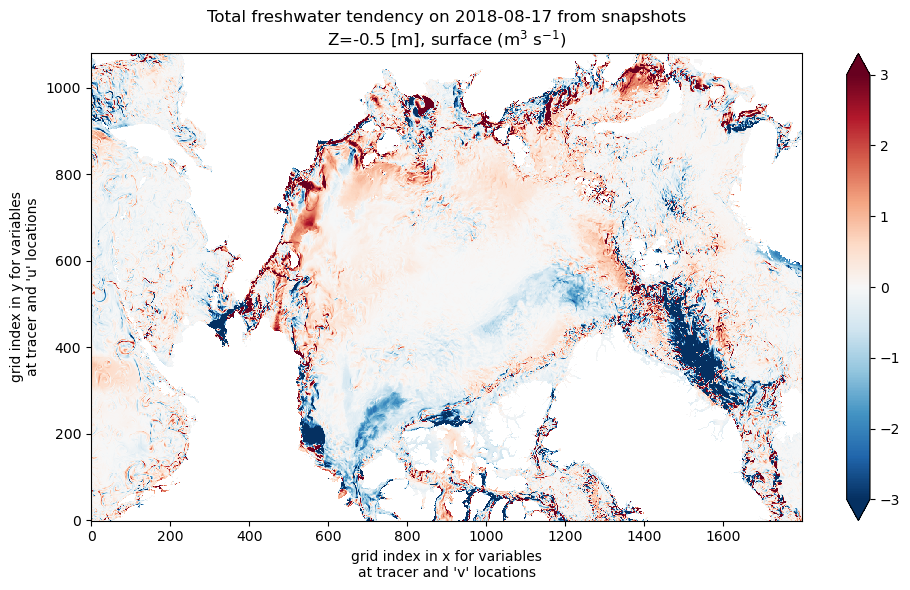

In [81]:
fig, (ax1) = plt.subplots(1,1,figsize=[10,6])
G_total.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-3,vmax=3);
Z = G_total.isel(k=0).Z.values
ax1.set_title(f"Total freshwater tendency on {str(salt_daily_snaps.time.values[0])[0:10]} from snapshots\nZ={Z} [m], surface (m$^3$ s$^{{-1}}$)");
plt.tight_layout()

### plot 55 m

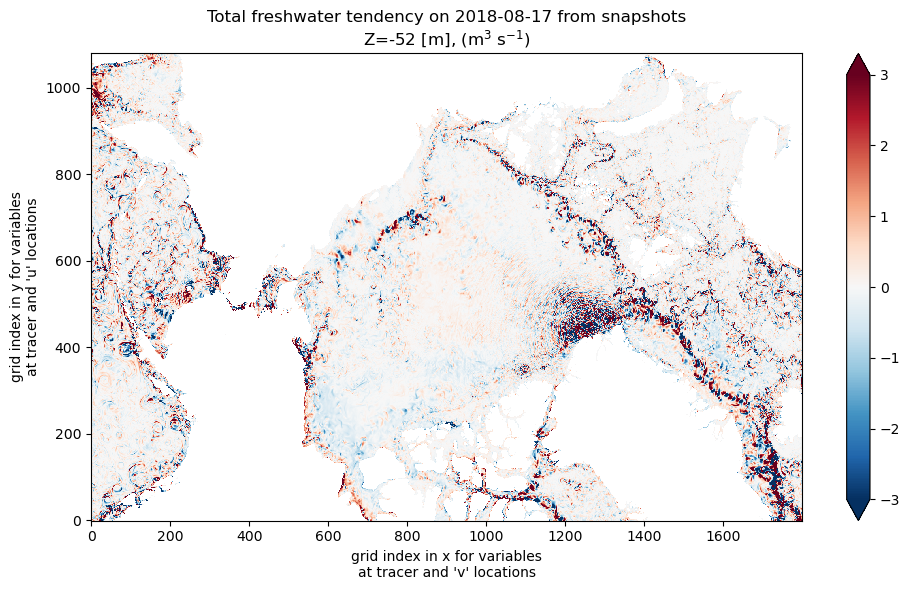

In [82]:
fig, (ax1) = plt.subplots(1,1,figsize=[10,6])
G_total.isel(k=16).plot(ax=ax1,cmap='RdBu_r',vmin=-3,vmax=3);
Z = G_total.isel(k=16).Z.values
ax1.set_title(f"Total freshwater tendency on {str(salt_daily_snaps.time.values[0])[0:10]} from snapshots\nZ={int(Z)} [m], (m$^3$ s$^{{-1}}$)");
plt.tight_layout()

# Calculate advective flux of freshwater ($G^{Fw}_\textrm{advection}$)

*Note*: there is no the Gent-McWilliams bolus velocity (i.e., the parameterization of unresolved eddy effects) in the SASSIE model.

In [30]:
def diff_2d_flux_HH(flux_vector_dict):
    """
    A function (similar to xgcm.Grid.diff_2d_vector) that differences flux variables on the HH Arctic grid.
    """

    u_flux = flux_vector_dict['X']
    v_flux = flux_vector_dict['Y']

    # take differences
    diff_u_flux = u_flux.diff('i_g')
    diff_v_flux = v_flux.diff('j_g')
    
    diff_u_flux_padded = diff_u_flux.pad(pad_width={'i_g':(1,0)},mode='constant',constant_values=np.nan)
    diff_v_flux_padded = diff_v_flux.pad(pad_width={'j_g':(1,0)},mode='constant',constant_values=np.nan)

    # include coordinates of input DataArrays and correct dimension/coordinate names
    diff_u_flux = diff_u_flux_padded.assign_coords(u_flux.coords).rename({'i_g':'i'})
    diff_v_flux = diff_v_flux_padded.assign_coords(v_flux.coords).rename({'j_g':'j'})

    diff_flux_vector_dict = {'X':diff_u_flux,'Y':diff_v_flux}

    return diff_flux_vector_dict

In [28]:
SALT_at_u = grid.interp(SALT_da, 'X', boundary='extend')
SALT_at_v = grid.interp(SALT_da, 'Y', boundary='extend')
SALT_at_w = grid.interp(SALT_da, 'Z', boundary='extend')

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a se

Check interpolation values:

In [29]:
print(SALT_da.isel(k=5,j=5,i=slice(0,5)).values)
print(SALT_at_u.isel(k=5,j=5,i_g=slice(0,5)).values)
print(SALT_at_v.isel(k=5,j_g=5,i=slice(0,5)).values)

[31.70959473 31.64506912 31.68527412 31.73232269 31.70584106]
[31.70959473 31.67733192 31.66517162 31.70879841 31.71908188]
[31.7345705  31.64335918 31.64558315 31.69015026 31.6929512 ]


In [31]:
# Freshwater advective (Eulerian) fluxes (m^3/s)
ADVx_FW = UVELMASS_da*HH_grid.dyG*HH_grid.drF*(Sref-SALT_at_u)/Sref
ADVy_FW = VVELMASS_da*HH_grid.dxG*HH_grid.drF*(Sref-SALT_at_v)/Sref
ADVr_FW = WVELMASS_da*HH_grid.rAc*(Sref-SALT_at_w)/Sref

In [32]:
# set fluxes on land to zero (instead of NaN)
ADVx_FW = ADVx_FW.where(HH_grid.hFacW.values > 0,0)
ADVy_FW = ADVy_FW.where(HH_grid.hFacS.values > 0,0)
ADVr_FW = ADVr_FW.where(HH_grid.hFacC.values > 0,0)

ADVxy_diff = diff_2d_flux_HH({'X': ADVx_FW.load(), \
                              'Y': ADVy_FW.load()})

# Convergence of horizontal advection (m^3/s)
adv_hConvFw = (-(ADVxy_diff['X'] + ADVxy_diff['Y']))

In [42]:
# Convergence of vertical advection (m^3/s)
# Pad the bottom
ADVr_FW_padded = ADVr_FW.pad(pad_width={'k_l':(0,1)},mode='constant',constant_values=0)

# Take differences
ADVz_diff = ADVr_FW_padded.diff('k_l').compute()

# change dim name
adv_vConvFw = ADVz_diff.assign_coords(ADVr_FW.coords).rename({'k_l':'k'})

# this also works using xgcm
# adv_vConvFw_xgcm = grid.diff(ADVr_FW, 'Z', boundary='fill')

In [89]:
# Sum horizontal and vertical convergences (m^3/s)
G_advection = adv_hConvFw + adv_vConvFw

### Plot the surface

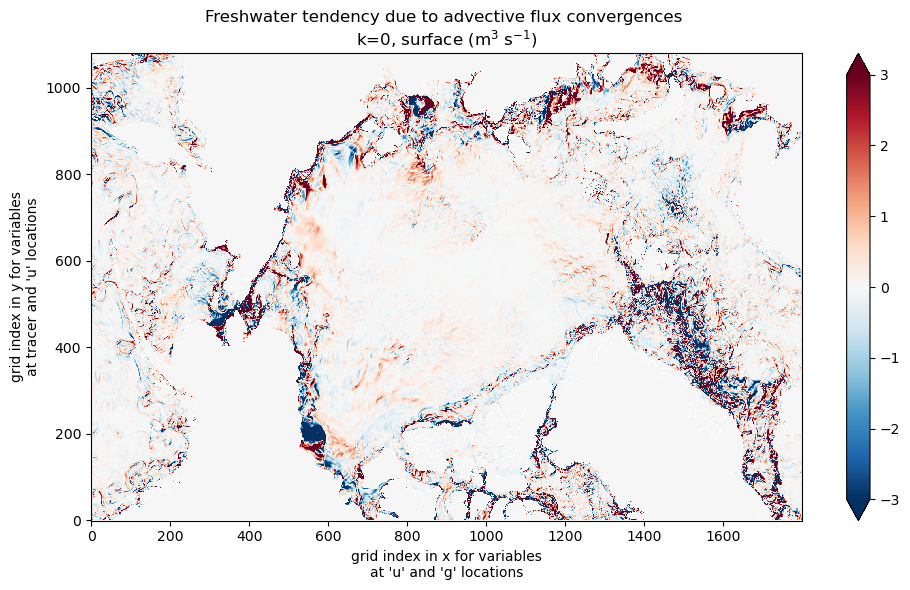

In [76]:
fig, (ax1) = plt.subplots(1,1,figsize=[10,6])
G_advection.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-3,vmax=3);
ax1.set_title("Freshwater tendency due to advective flux convergences \nk=0, surface (m$^3$ s$^{{-1}}$)")
plt.tight_layout()

# Freshwater forcing

The forcing term is equal to the salinity forcing divided by the reference salinity

In [65]:
# Seawater density
rhoconst = 1027.5 # (kg/m^3)

In [128]:
# converting g m-2 s-1 --> psu/s
forcS = SFLUX_da / (rhoconst * HH_grid.drF.isel(k=0) * HH_grid.hFacC.isel(k=0))

# add vertical coordinate
G_forcing_Sln = forcS.assign_coords(k=0).expand_dims('k')

# expand k dim to be 90 vertical levels but with zeros below the surface
G_forcing_Sln = xr.concat([G_forcing_Sln, xr.zeros_like((SFLUX_da[0])/(HH_grid.hFacC).isel(k=slice(1,None)))],dim='k')

In [117]:
# the ecco freshwater budget tutorial uses oceFWflx but I don't think it is required for this model configuration

# # Freshwater forcing, convert units from [kg/m^2/s] to [m^3/s]
# forcFw = oceFWflx_da / rhoconst*HH_grid.rAc

# # add vertical coordinate
# forcFw = forcFw.assign_coords(k=0).expand_dims('k')

# # expand k dim to be 90 vertical levels but with zeros below the surface
# forcing_Fw = xr.concat([forcFw, xr.zeros_like(HH_grid.hFacC.isel(k=slice(1,None)).drop_vars('Z'))],dim='k')

In [130]:
# divide by reference salinity and convert to m^3/s
# G_forcing = forcing_Fw-(G_forcing_Sln/Sref*vol_sassie)
G_forcing = G_forcing_Sln/Sref*vol_sassie

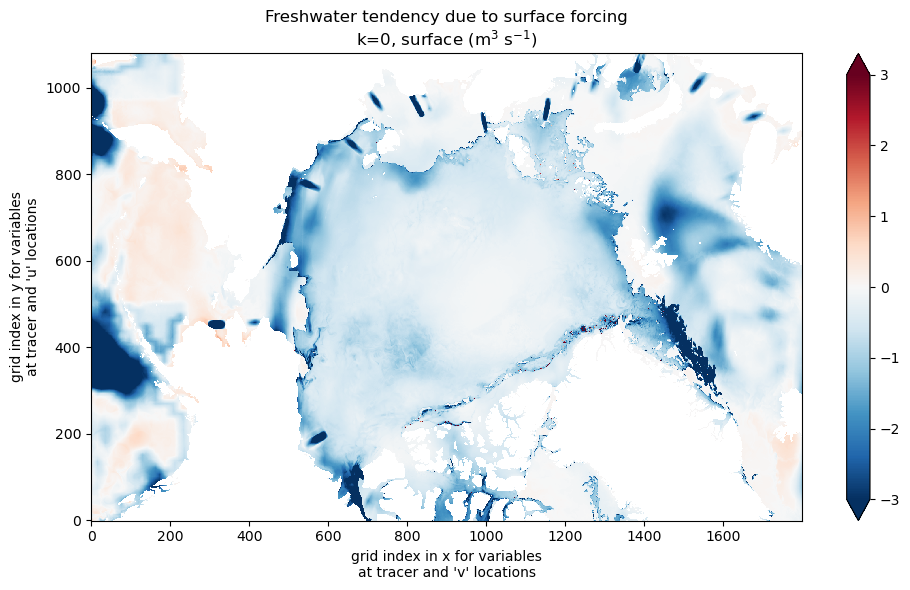

In [135]:
fig, (ax1) = plt.subplots(1,1,figsize=[10,6])
G_forcing.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-3,vmax=3);
ax1.set_title("Freshwater tendency due to surface forcing\nk=0, surface (m$^3$ s$^{{-1}}$)")
plt.tight_layout()

# Diffusive freshwater flux

The diffusive freshwater flux is computed as the residuals of the remaining budget terms because this term is not output by the model.

In [132]:
# Convergence of freshwater diffusion (m^3/s)
G_diffusion = G_total - G_forcing - G_advection

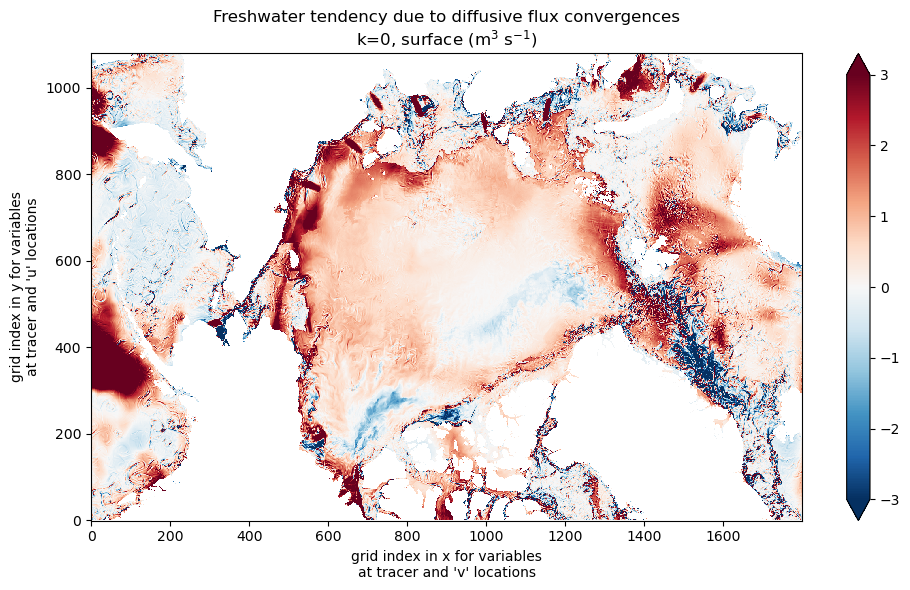

In [136]:
fig, (ax1) = plt.subplots(1,1,figsize=[10,6])
G_diffusion.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-3,vmax=3);
ax1.set_title("Freshwater tendency due to diffusive flux convergences\nk=0, surface (m$^3$ s$^{{-1}}$)")
plt.tight_layout()

# Examine all components of budget

In [134]:
# double check dims
print(G_advection.shape)
print(G_diffusion.shape)
print(G_forcing.shape)

(90, 1080, 1800)
(90, 1080, 1800)
(90, 1080, 1800)


### Plot all components

Start with the surface

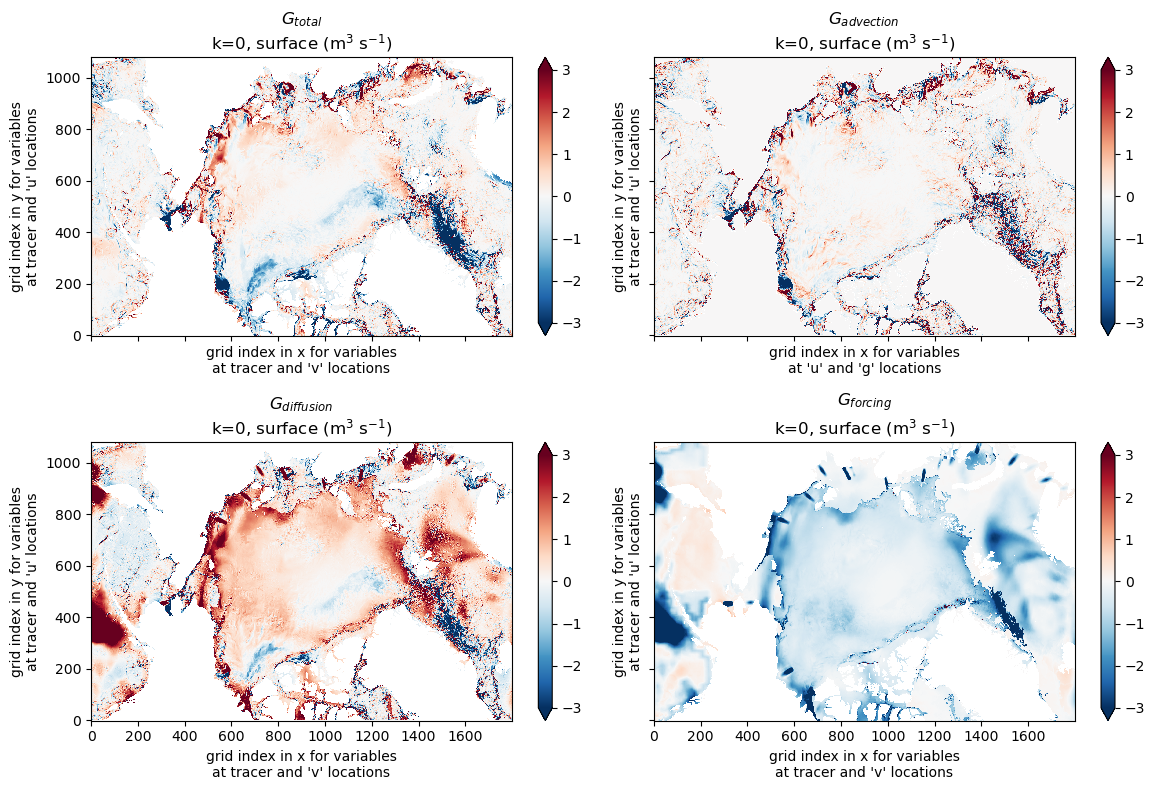

In [140]:
fig, ((ax1, ax2),(ax3, ax4)) = plt.subplots(2,2,figsize=[12,8],sharey=True,sharex=True)
G_total.isel(k=0).plot(ax=ax1,cmap='RdBu_r',vmin=-3,vmax=3);
G_advection.isel(k=0).plot(ax=ax2,cmap='RdBu_r',vmin=-3,vmax=3);
G_diffusion.isel(k=0).plot(ax=ax3,cmap='RdBu_r',vmin=-3,vmax=3);
G_forcing.isel(k=0).plot(ax=ax4,cmap='RdBu_r',vmin=-3,vmax=3);

ax1.set_title("$G_{total}$\nk=0, surface (m$^3$ s$^{{-1}}$)")
ax2.set_title("$G_{advection}$\nk=0, surface (m$^3$ s$^{{-1}}$)")
ax3.set_title("$G_{diffusion}$\nk=0, surface (m$^3$ s$^{{-1}}$)")
ax4.set_title("$G_{forcing}$\nk=0, surface (m$^3$ s$^{{-1}}$)")
plt.tight_layout()

Then deeper level

In [147]:
G_total.isel(k=21).Z.values

array(-99.37, dtype=float32)

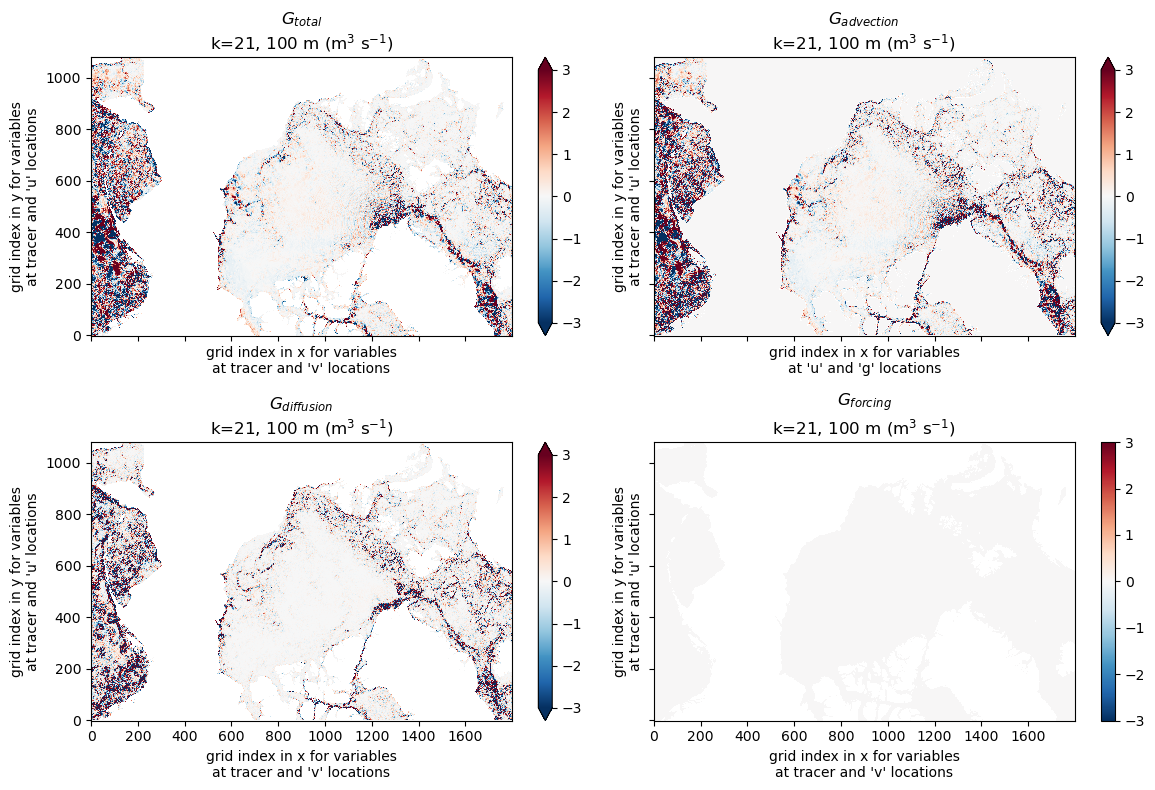

In [148]:
fig, ((ax1, ax2),(ax3, ax4)) = plt.subplots(2,2,figsize=[12,8],sharey=True,sharex=True)
G_total.isel(k=21).plot(ax=ax1,cmap='RdBu_r',vmin=-3,vmax=3);
G_advection.isel(k=21).plot(ax=ax2,cmap='RdBu_r',vmin=-3,vmax=3);
G_diffusion.isel(k=21).plot(ax=ax3,cmap='RdBu_r',vmin=-3,vmax=3);
G_forcing.isel(k=21).plot(ax=ax4,cmap='RdBu_r',vmin=-3,vmax=3);

ax1.set_title("$G_{total}$\nk=21, 100 m (m$^3$ s$^{{-1}}$)")
ax2.set_title("$G_{advection}$\nk=21, 100 m (m$^3$ s$^{{-1}}$)")
ax3.set_title("$G_{diffusion}$\nk=21, 100 m (m$^3$ s$^{{-1}}$)")
ax4.set_title("$G_{forcing}$\nk=21, 100 m (m$^3$ s$^{{-1}}$)")
plt.tight_layout()

### Next we will use one `j` row (j=500) to compare each component of the freshwater budget

Start with the surface

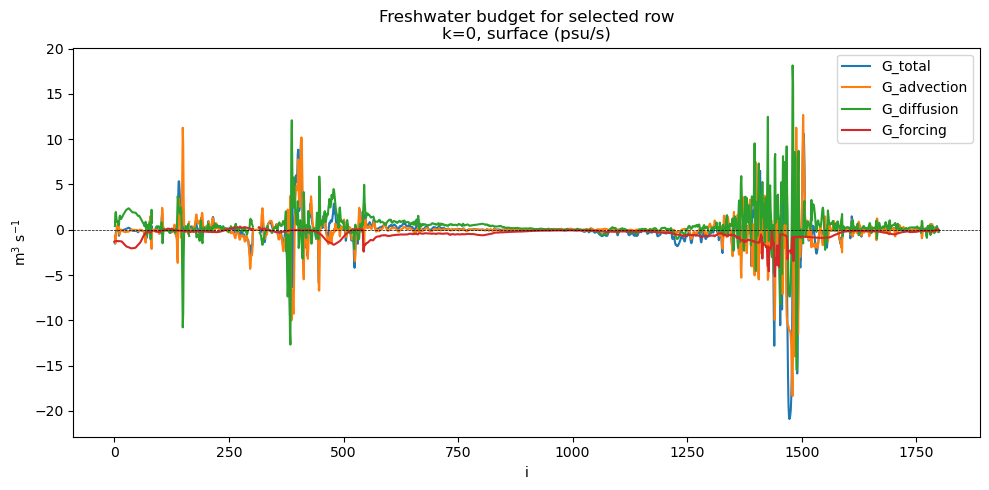

In [142]:
fig, (ax1) = plt.subplots(1,1,figsize=[10,5])
ax1.set_title('Freshwater budget for selected row\nk=0, surface (m$^3$ s$^{{-1}}$)')

# ax1.set_title('sassie')
ax1.plot(G_total.isel(j=500,k=0),label='G_total')
ax1.plot(G_advection.isel(j=500,k=0),label='G_advection')
ax1.plot(G_diffusion.isel(j=500,k=0),label='G_diffusion')
ax1.plot(G_forcing.isel(j=500,k=0),label='G_forcing')

ax1.set_xlabel("i")
ax1.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

# ax1.set_ylim(-6e-5,6e-5)
ax1.set_ylabel('m$^3$ s$^{{-1}}$')
# ax1.set_xlim(0,400)
# ax2.set_xlim(0,33)
plt.tight_layout()
ax1.legend();

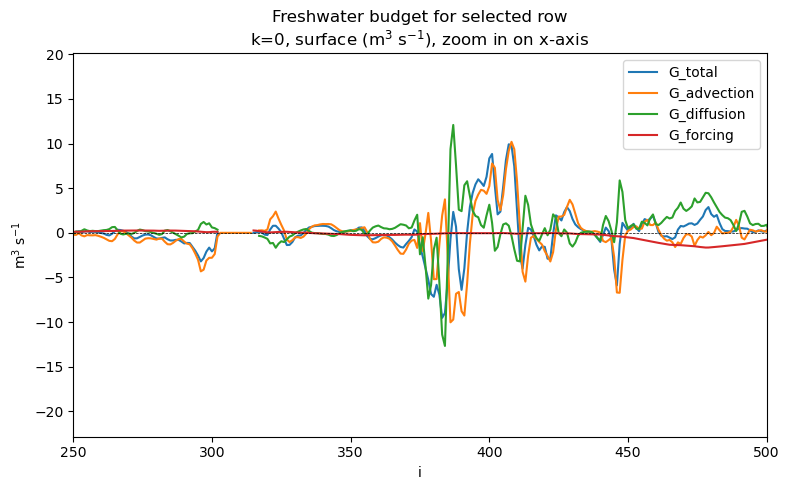

In [144]:
fig, (ax1) = plt.subplots(1,1,figsize=[8,5])
ax1.set_title('Freshwater budget for selected row\nk=0, surface (m$^3$ s$^{{-1}}$), zoom in on x-axis')

# ax1.set_title('sassie')
ax1.plot(G_total.isel(j=500,k=0),label='G_total')
ax1.plot(G_advection.isel(j=500,k=0),label='G_advection')
ax1.plot(G_diffusion.isel(j=500,k=0),label='G_diffusion')
ax1.plot(G_forcing.isel(j=500,k=0),label='G_forcing')

ax1.set_xlabel("i")
ax1.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

# ax1.set_ylim(-6e-5,6e-5)
ax1.set_ylabel('m$^3$ s$^{{-1}}$')
ax1.set_xlim(250,500)
# ax2.set_xlim(0,33)
plt.tight_layout()
ax1.legend();

Then go deeper

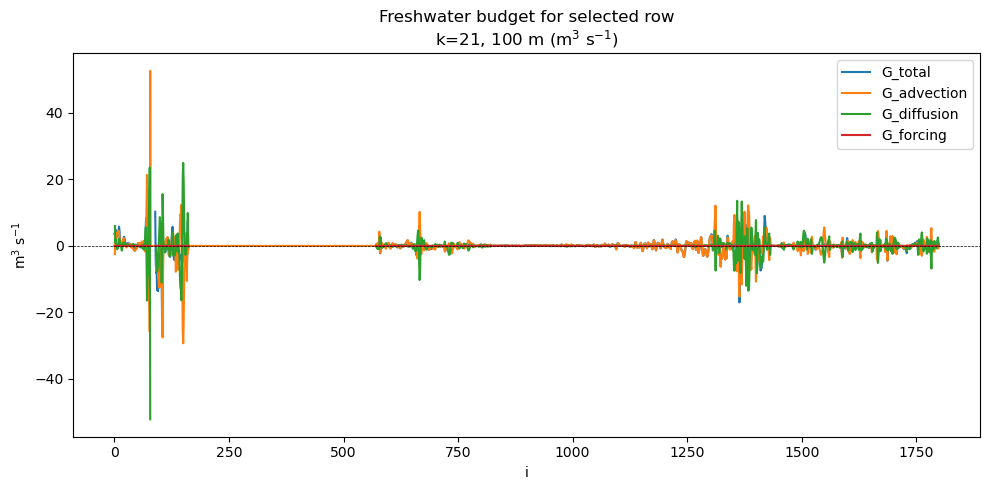

In [149]:
fig, (ax1) = plt.subplots(1,1,figsize=[10,5])
ax1.set_title('Freshwater budget for selected row\nk=21, 100 m (m$^3$ s$^{{-1}}$)')

# ax1.set_title('sassie')
ax1.plot(G_total.isel(j=500,k=21),label='G_total')
ax1.plot(G_advection.isel(j=500,k=21),label='G_advection')
ax1.plot(G_diffusion.isel(j=500,k=21),label='G_diffusion')
ax1.plot(G_forcing.isel(j=500,k=21),label='G_forcing')

ax1.set_xlabel("i")
ax1.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

# ax1.set_ylim(-6e-5,6e-5)
ax1.set_ylabel('m$^3$ s$^{{-1}}$')
# ax1.set_xlim(0,400)
# ax2.set_xlim(0,33)
plt.tight_layout()
ax1.legend();

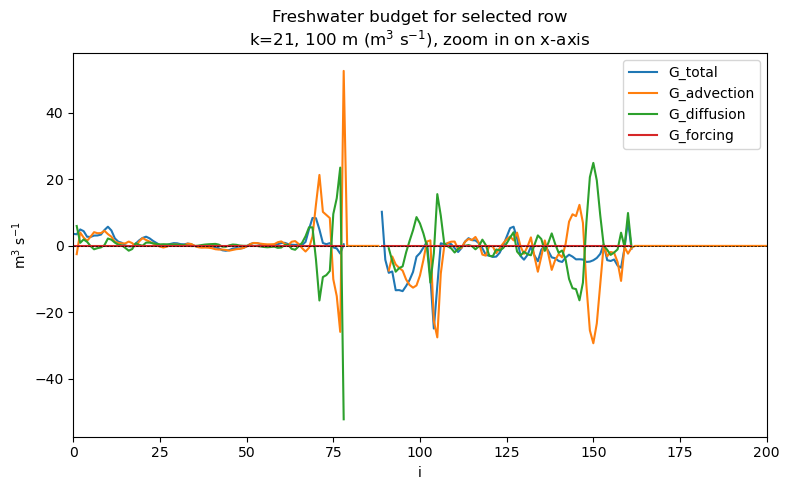

In [151]:
fig, (ax1) = plt.subplots(1,1,figsize=[8,5])
ax1.set_title('Freshwater budget for selected row\nk=21, 100 m (m$^3$ s$^{{-1}}$), zoom in on x-axis')

# ax1.set_title('sassie')
ax1.plot(G_total.isel(j=500,k=21),label='G_total')
ax1.plot(G_advection.isel(j=500,k=21),label='G_advection')
ax1.plot(G_diffusion.isel(j=500,k=21),label='G_diffusion')
ax1.plot(G_forcing.isel(j=500,k=21),label='G_forcing')

ax1.set_xlabel("i")
ax1.axhline(y=0,color='k',linewidth=0.5,linestyle='dashed');

# ax1.set_ylim(-6e-5,6e-5)
ax1.set_ylabel('m$^3$ s$^{{-1}}$')
ax1.set_xlim(0,200)
# ax2.set_xlim(0,33)
plt.tight_layout()
ax1.legend();